# AI-Driven Sales Forecasting and Inventory Optimisation using Machine Learning.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import kagglehub
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import sqlite3
import shap
import requests
import json


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense,Conv1D,
MaxPooling1D,Flatten,Input,Dropout,BatchNormalization)
from tensorflow.keras.callbacks import (EarlyStopping,ReduceLROnPlateau)


from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier
import lightgbm as lgb

from sklearn.metrics import (accuracy_score
,classification_report,
confusion_matrix,
precision_score,
recall_score,
f1_score,
roc_auc_score,
silhouette_score,
adjusted_rand_score)

from sklearn.ensemble import RandomForestClassifier

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

from IPython.display import FileLink


2026-06-11 15:15:09.108092: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781190909.350756      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781190909.422502      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781190910.009264      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781190910.009338      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781190910.009342      58 computation_placer.cc:177] computation placer alr

In [4]:
# Download latest version
path = kagglehub.dataset_download("dhrubangtalukdar/store-item-demand-forecasting-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/dhrubangtalukdar/store-item-demand-forecasting-dataset


In [5]:
# Show all files inside the folder
print("\nFiles in dataset folder:")
print(os.listdir(path))


Files in dataset folder:
['retail_sales.csv']


In [6]:
# Load the CSV file
csv_file = os.path.join(path, 'retail_sales.csv')

# Read dataset into pandas dataframe
df = pd.read_csv(csv_file)
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


In [9]:
# Print dataset information
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      object 
 1   store_id  object 
 2   item_id   object 
 3   sales     int64  
 4   price     float64
 5   promo     int64  
 6   weekday   int64  
 7   month     int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 278.6+ MB


In [7]:
# Print dataset structure
print("\nDataset structure:")
df.describe()


Dataset structure:


,sales,price,promo,weekday,month
count,4.565000e+06,4.565000e+06,4.565000e+06,4.565000e+06,4.565000e+06
mean,2.926466e+01,5.399323e+01,9.999869e-02,3.001643e+00,6.523549e+00
std,1.500996e+01,2.578461e+01,2.999983e-01,1.999315e+00,3.448534e+00
min,0.000000e+00,8.020000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,1.800000e+01,3.197000e+01,0.000000e+00,1.000000e+00,4.000000e+00
50%,2.700000e+01,5.352000e+01,0.000000e+00,3.000000e+00,7.000000e+00
75%,3.800000e+01,7.536000e+01,0.000000e+00,5.000000e+00,1.000000e+01
max,1.390000e+02,9.999000e+01,1.000000e+00,6.000000e+00,1.200000e+01


In [8]:
# SQL- style ingestion 
conn = sqlite3.connect("retail_sales.db")

# Store dataframe into SQL table
df.to_sql(
    "sales_data",
    conn,
    if_exists="replace",
    index=False)

print('Dataset stored successfully')

Dataset stored successfully


In [13]:
# SQL Querying 
query = """
SELECT store_id AS store,
       item_id AS item,
       AVG(sales) AS avg_sales
FROM sales_data
GROUP BY store_id, item_id
"""
# Execute query
sales_summary = pd.read_sql(query, conn)

# Print result
print(sales_summary.head())

     store     item  avg_sales
0  store_1   item_1  44.780942
1  store_1  item_10  22.625958
2  store_1  item_11  24.568456
3  store_1  item_12  20.680175
4  store_1  item_13  39.995619


# 4. DATA PRE-PROCESSING

In [12]:
# 4.1 Missing Values
print(df.isnull().sum())

date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64


In [13]:
## 4.2 Duplicate Records 
print(df.duplicated().sum())

0


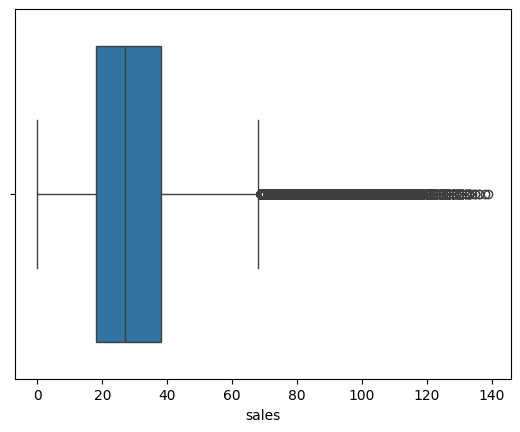

In [9]:
# 4.3 Outlier Detection 
sns.boxplot(x=df['sales'])

plt.show()

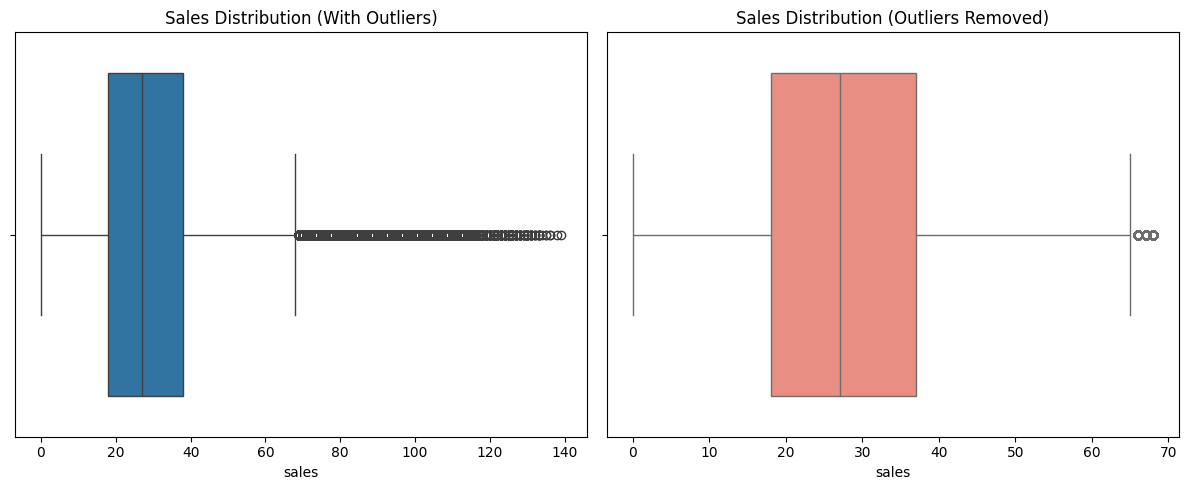

In [10]:
Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)

IQR = Q3 - Q1

df_clean = df[
    ~((df['sales'] < (Q1 - 1.5 * IQR)) |
      (df['sales'] > (Q3 + 1.5 * IQR)))].copy()

# 2. Set up a side-by-side plotting area
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Before
sns.boxplot(x=df['sales'], ax=axes[0])
axes[0].set_title('Sales Distribution (With Outliers)')

# Plot After
sns.boxplot(data=df_clean, x='sales', ax=axes[1], color='salmon')
axes[1].set_title('Sales Distribution (Outliers Removed)')

plt.tight_layout()
plt.show()

#### 4.4 Feature Engineering

In [11]:
df_clean.ffill(inplace=True)

In [12]:
# Convert date column
df_clean['date'] = pd.to_datetime(df_clean['date'])

In [13]:
# Creating time-based features

df_clean['month'] = df_clean['date'].dt.month

df_clean['day_of_week'] = df_clean['date'].dt.dayofweek

df_clean['year'] = df_clean['date'].dt.year

In [14]:
# creating historical sales features
df_clean['lag_7'] = df_clean.groupby(["store_id","item_id"])['sales'].shift(7)

df_clean['lag_30'] = df_clean.groupby(["store_id","item_id"])['sales'].shift(30)

# Rolling mean

df_clean['rolling_mean_7'] = (df_clean.groupby(["store_id","item_id"])['sales']
                              .rolling(window=7)
                              .mean()
                              .reset_index(level=[0, 1], drop= True))
                              

df_clean['rolling_mean_30'] = (df_clean.groupby(["store_id","item_id"])['sales']
                               .rolling(window=30)
                               .mean()
                               .reset_index(level=[0, 1], drop= True))

In [15]:
# Remove NaN values created by LAGS
df_clean.dropna(inplace=True)

In [16]:
# Create Demand Classes

def classify_demand(x):

    if x < 30:
        return 0

    elif x < 60:
        return 1

    else:
        return 2

df_clean['demand_class'] = (df_clean['sales']
                           .apply(classify_demand))


In [17]:
# Select Features
features = [
    'store_id',
    'item_id',
    'month',
    'day_of_week',
    'lag_7',
    'rolling_mean_7',
    'rolling_mean_30']

X = df_clean[features]

y = df_clean['demand_class']

print(X.head())

   store_id item_id  month  day_of_week  lag_7  rolling_mean_7  \
30  store_1  item_1      1            3   40.0       44.142857   
31  store_1  item_1      2            4   38.0       44.571429   
32  store_1  item_1      2            5   34.0       44.571429   
33  store_1  item_1      2            6   40.0       43.714286   
34  store_1  item_1      2            0   44.0       46.571429   

    rolling_mean_30  
30        43.066667  
31        42.666667  
32        42.500000  
33        42.466667  
34        42.900000  


In [18]:
#Convert categorical text columns into 0s and 1s
X_encoded = pd.get_dummies(df_clean.drop(columns=['sales', 'date']), columns=['store_id', 'item_id'])

In [19]:
# Scale feature
scaler = StandardScaler() 

X_scaled = scaler.fit_transform(X_encoded)

### 4.6  EXPLORATORY DATA ANALYSIS (EDA)

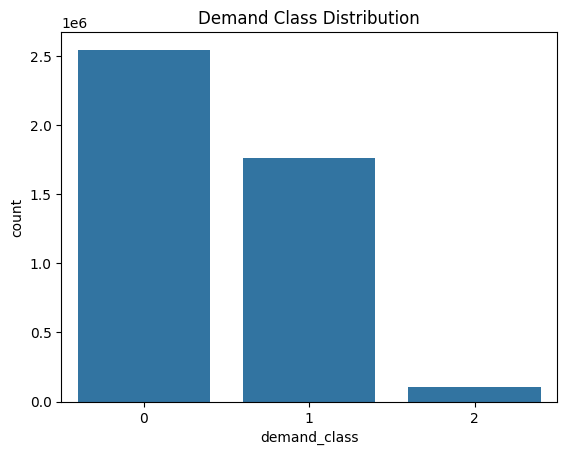

In [23]:
# Checking Class Distribution 
sns.countplot(
    x='demand_class',
    data=df_clean)

plt.title("Demand Class Distribution")

plt.show()

<Figure size 1000x500 with 0 Axes>

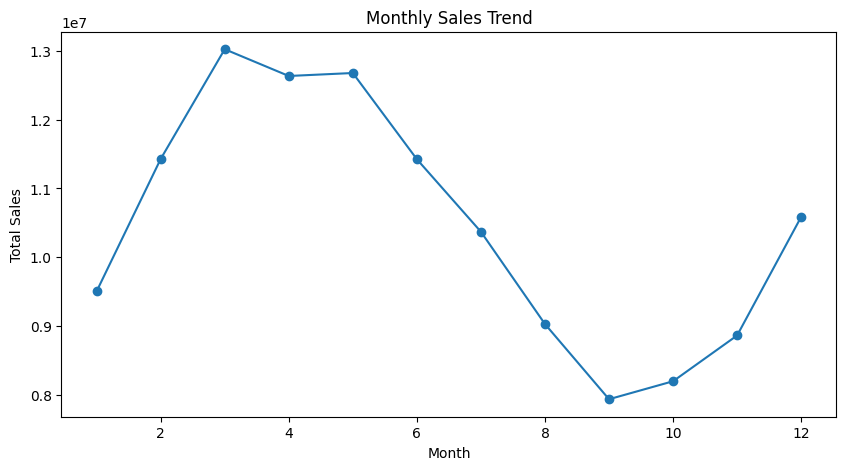

In [24]:
# Analyse monthly sales trend

plt.figure(figsize=(10,5))

# Monthly trend

monthly_sales = (
    df_clean.groupby('month')['sales']
    .sum()
    .reset_index())

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales['month'],
    monthly_sales['sales'],
    marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

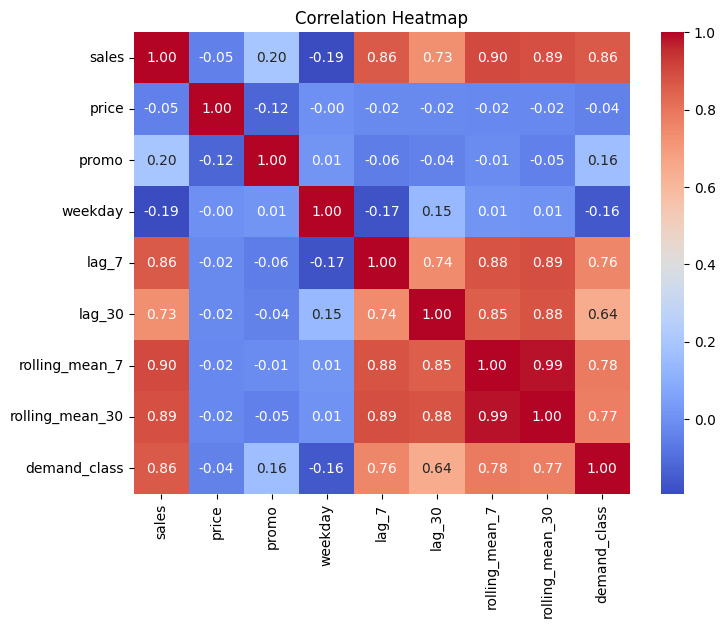

In [25]:
#Analysing Correlation Heatmap

# Select numerical columns
numeric_df = df_clean.select_dtypes(include=['int64','float64'])

# Correlation matrix
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f')

plt.title("Correlation Heatmap")

plt.show()

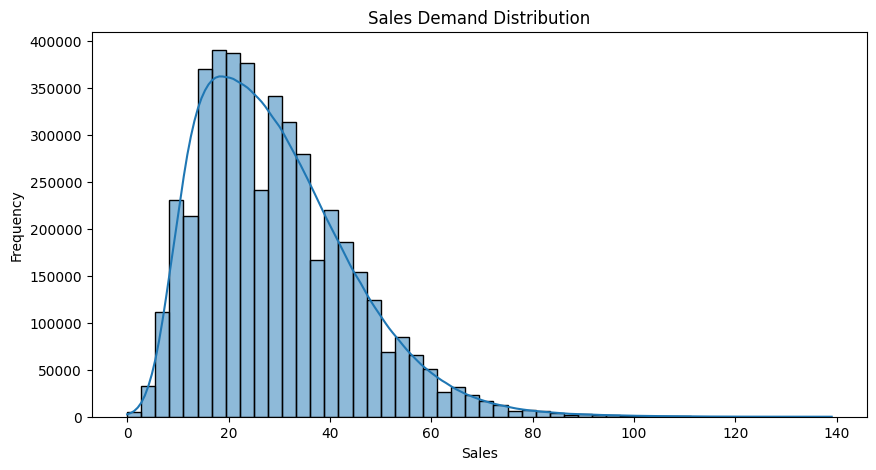

In [26]:
#Demand Distribution Plot

plt.figure(figsize=(10,5))

sns.histplot(
    df['sales'],
    bins=50,
    kde=True)

plt.title("Sales Demand Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

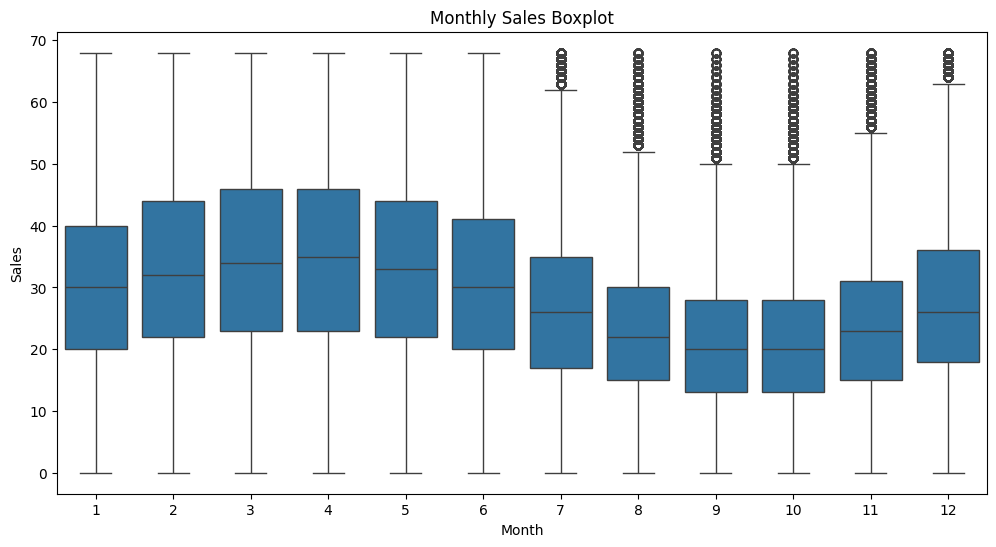

In [27]:
# Boxplot

plt.figure(figsize=(12,6))

sns.boxplot(
    x='month',
    y='sales',
    data=df_clean)

plt.title("Monthly Sales Boxplot")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

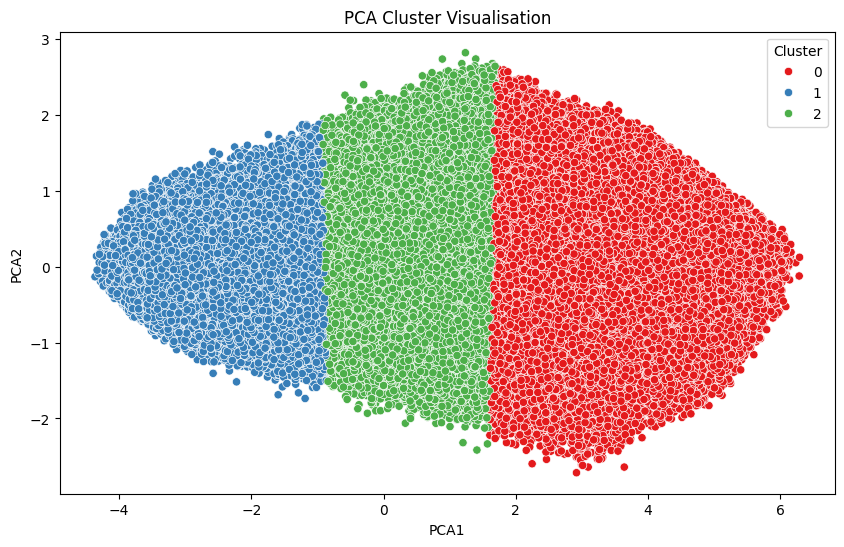

In [34]:
# PCA Cluster Visualisation 
pca_features = df_clean[[
    'sales',
    'lag_7',
    'lag_30',
    'rolling_mean_7',
    'rolling_mean_30']]

# Standardise data
scaler = StandardScaler()

scaled_data = scaler.fit_transform(pca_features)

# PCA transformation
pca = PCA(n_components=2)

pca_components = pca.fit_transform(scaled_data)

# KMeans clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42)

clusters = kmeans.fit_predict(pca_components)

# Create PCA dataframe
pca_df = pd.DataFrame(
    data=pca_components,
    columns=['PCA1','PCA2'])

pca_df['Cluster'] = clusters

# Plot PCA clusters
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=pca_df,
    palette='Set1')

plt.title("PCA Cluster Visualisation")

plt.show()

#### 4.7 FEATURE SCALING + TRAIN TEST SPLIT

#### Chronological Train Test Split

In [20]:
# Prevent data leakage
# Calculate the split point index  (80% train, 20% test)

df_clean = df_clean.sort_values("date")

split = int(len(df_clean)*0.80)

train = df_clean.iloc[:split]

test = df_clean.iloc[split:]

features = [
'price',
'promo',
'month',
'day_of_week',
'lag_7',
'lag_30',
'rolling_mean_7',
'rolling_mean_30']

X_train = train[features]
X_test = test[features]

y_train = train["demand_class"]
y_test = test["demand_class"]

In [21]:
# Pipeline & Scaling

numerical_features = [
'price',
'lag_7',
'lag_30',
'rolling_mean_7',
'rolling_mean_30']

categorical_features = [
'promo',
'month',
'day_of_week']

preprocessor = ColumnTransformer(
transformers=[
('num',
StandardScaler(),
numerical_features),
('cat',
'passthrough',
categorical_features)])

X_train_scaled = preprocessor.fit_transform(X_train)

X_test_scaled = preprocessor.transform(X_test)

# 5. Implementation and Evaluation

#### 5.1 Multilayer Perceptron (MLP)

In [22]:
# Basic MLP Model 
def build_basic_mlp(input_dim):
    
    model = Sequential([
        Dense(15, activation='relu', input_shape=(input_dim,)),
        Dense(25, activation='relu'),
        Dense(25, activation='relu'),
        Dense(20, activation='relu'),
        Dense(3, activation='softmax')])
    
    model.compile(optimizer='adam'
                  ,loss='sparse_categorical_crossentropy'
                  ,metrics=['accuracy'])
    return model

In [23]:
# Build and train basic model
basic_mlp_model = build_basic_mlp(input_dim=X_train_scaled.shape[1])

print("Training Basic MLP...")
basic_history = basic_mlp_model.fit(
    X_train_scaled, y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=2048,  # Increased for speed optimization
    verbose=1)

# 2. Evaluate Basic
basic_loss, basic_acc = basic_mlp_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nBasic MLP Final Test Accuracy: {basic_acc:.4f}")

2026-06-11 15:30:57.824346: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Training Basic MLP...
Epoch 1/50
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9117 - loss: 0.2057 - val_accuracy: 0.9217 - val_loss: 0.1771
Epoch 2/50
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9281 - loss: 0.1637 - val_accuracy: 0.9245 - val_loss: 0.1712
Epoch 3/50
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9295 - loss: 0.1604 - val_accuracy: 0.9242 - val_loss: 0.1721
Epoch 4/50
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9302 - loss: 0.1587 - val_accuracy: 0.9261 - val_loss: 0.1672
Epoch 5/50
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9307 - loss: 0.1576 - val_accuracy: 0.9264 - val_loss: 0.1667
Epoch 6/50
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9309 - loss: 0.1570 - val_accuracy: 0.9253 - val_loss: 0.1686
Epoch 7/50
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9309 - loss: 0.1568 - val_accuracy: 0.9261 - val_loss: 0.1669
Epoch 8/50
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.

In [24]:
y_pred_prob = basic_mlp_model.predict(X_test_scaled)

y_pred = np.argmax(y_pred_prob,axis=1)

print(classification_report(y_test,y_pred))

27599/27599 ━━━━━━━━━━━━━━━━━━━━ 29s 1ms/step
              precision    recall  f1-score   support

           0       0.94      0.95      0.94    449343
           1       0.92      0.92      0.92    400747
           2       0.86      0.68      0.76     33063

    accuracy                           0.93    883153
   macro avg       0.91      0.85      0.87    883153
weighted avg       0.92      0.93      0.92    883153



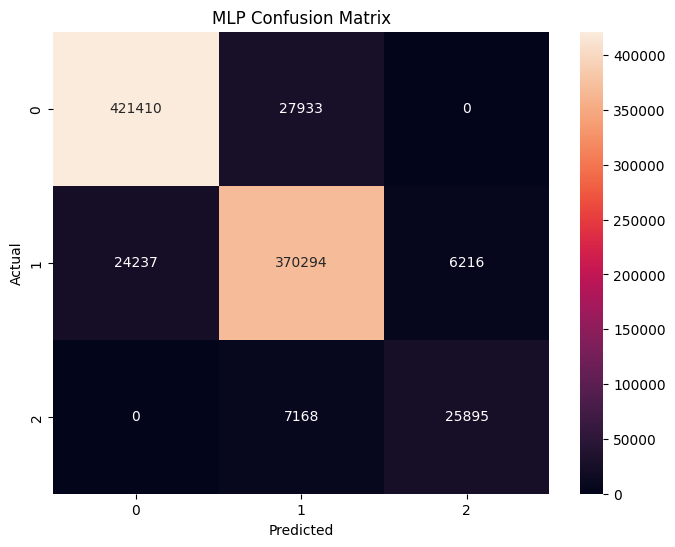

In [30]:
cm = confusion_matrix(
    y_test,
    y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d")

plt.title("MLP Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### 5.1.1 Advance MLP

In [25]:
def build_advanced_mlp(input_dim):
    
    model = Sequential([
        # Hidden Layer 1 Block
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        
        # Hidden Layer 2 Block
        Dense(25, activation='relu'),
        BatchNormalization(),
        Dropout(0.1),
        
        # Hidden Layer 3 Block
        Dense(32, activation='relu'),
        BatchNormalization(),
        
        
        # Hidden Layer 4 Block
        Dense(16, activation='relu'),
        
        # Output Layer
        Dense(3, activation='softmax')])
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])
    return model

In [27]:
# Callback
early_stop = EarlyStopping(monitor='val_loss',patience=10
                           ,restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss'
                              ,factor=0.5, patience=5)

# Build and train advanced model
advanced_mlp_model = build_advanced_mlp(input_dim=X_train_scaled.shape[1])

print("Training Advanced MLP...")
advanced_history = advanced_mlp_model.fit(
    X_train_scaled, y_train,
    validation_split=0.20,
    epochs=100,      
    batch_size=2048,  # Increased for speed optimization
    callbacks=[early_stop, reduce_lr],
    verbose=1)

# Evaluate Advanced
adv_loss, adv_acc = advanced_mlp_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nAdvanced MLP Final Test Accuracy: {adv_acc:.4f}")

I0000 00:00:1780962546.887624      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780962546.893421      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Training Advanced MLP...
Epoch 1/100


I0000 00:00:1780962551.269681     132 service.cc:152] XLA service 0x7da4dc005cc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780962551.269716     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780962551.269720     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780962551.800668     132 cuda_dnn.cc:529] Loaded cuDNN version 91002


  50/1380 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6970 - loss: 0.7184

I0000 00:00:1780962554.498091     132 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.9214 - loss: 0.1847 - val_accuracy: 0.9250 - val_loss: 0.1693 - learning_rate: 0.0010
Epoch 2/100
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9290 - loss: 0.1615 - val_accuracy: 0.9259 - val_loss: 0.1673 - learning_rate: 0.0010
Epoch 3/100
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9296 - loss: 0.1600 - val_accuracy: 0.9263 - val_loss: 0.1662 - learning_rate: 0.0010
Epoch 4/100
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9299 - loss: 0.1591 - val_accuracy: 0.9264 - val_loss: 0.1661 - learning_rate: 0.0010
Epoch 5/100
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9301 - loss: 0.1587 - val_accuracy: 0.9240 - val_loss: 0.1713 - learning_rate: 0.0010
Epoch 6/100
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9302 - loss: 0.1583 - val_accuracy: 0.9272 - val_loss: 0.1646 - learning_rate: 0.0010
Epoch 7/100
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9304 - loss:

In [28]:
# Predict probabilities using the correct scaled dataset and large batch size
mlp_pred_prob = advanced_mlp_model.predict(X_test_scaled, batch_size=2048)

# Extract the index positions of the highest class probabilities
mlp_pred = np.argmax(mlp_pred_prob, axis=1)

# Output clean evaluation metrics
print(classification_report(y_test, mlp_pred))

432/432 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

           0       0.94      0.94      0.94    449343
           1       0.91      0.92      0.92    400747
           2       0.84      0.74      0.78     33063

    accuracy                           0.93    883153
   macro avg       0.90      0.87      0.88    883153
weighted avg       0.93      0.93      0.93    883153



### 5.2 Ensemble Model

#### 5.2.1 XGBoost model

In [40]:
xgb = XGBClassifier(
n_estimators=200,
max_depth=6,
learning_rate=0.05,
random_state=42)

xgb.fit(
X_train_scaled,
y_train)

pred_xgb = xgb.predict(
X_test_scaled)

print(
classification_report(
y_test,
pred_xgb))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94    449343
           1       0.92      0.92      0.92    400747
           2       0.82      0.75      0.78     33063

    accuracy                           0.93    883153
   macro avg       0.89      0.87      0.88    883153
weighted avg       0.93      0.93      0.93    883153



#### 5.2.1 Advance LightGBM Model 

In [55]:
# lgbm Model
lgbm = lgb.LGBMClassifier(n_estimators=300
                          ,learning_rate=0.05
                          ,num_leaves=31
                          ,random_state=42)

lgbm.fit(X_train_scaled
         ,y_train)

pred_lgb = lgbm.predict(X_test_scaled)

print(classification_report(y_test,pred_lgb))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049709 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 927
[LightGBM] [Info] Number of data points in the train set: 3532611, number of used features: 8
[LightGBM] [Info] Start training from score -0.521290
[LightGBM] [Info] Start training from score -0.952759
[LightGBM] [Info] Start training from score -3.883905
              precision    recall  f1-score   support

           0       0.94      0.94      0.94    449343
           1       0.92      0.92      0.92    400747
           2       0.82      0.76      0.79     33063

    accuracy                           0.93    883153
   macro avg       0.89      0.88      0.88    883153
weighted avg       0.93      0.93      0.93    883153



In [56]:
lgb_acc = accuracy_score(
    y_test,
    pred_lgb)

print(f"LightGBM Accuracy: {lgb_acc:.2f}")

LightGBM Accuracy: 0.93


In [57]:
lgb_precision = precision_score(
    y_test,
    pred_lgb,
    average="weighted")

lgb_recall = recall_score(
    y_test,
    pred_lgb,
    average="weighted")

lgb_f1 = f1_score(
    y_test,
    pred_lgb,
    average="weighted")

print(f"Accuracy : {lgb_acc:.4f}")
print(f"Precision: {lgb_precision:.4f}")
print(f"Recall   : {lgb_recall:.4f}")
print(f"F1 Score : {lgb_f1:.4f}")

Accuracy : 0.9262
Precision: 0.9260
Recall   : 0.9262
F1 Score : 0.9261


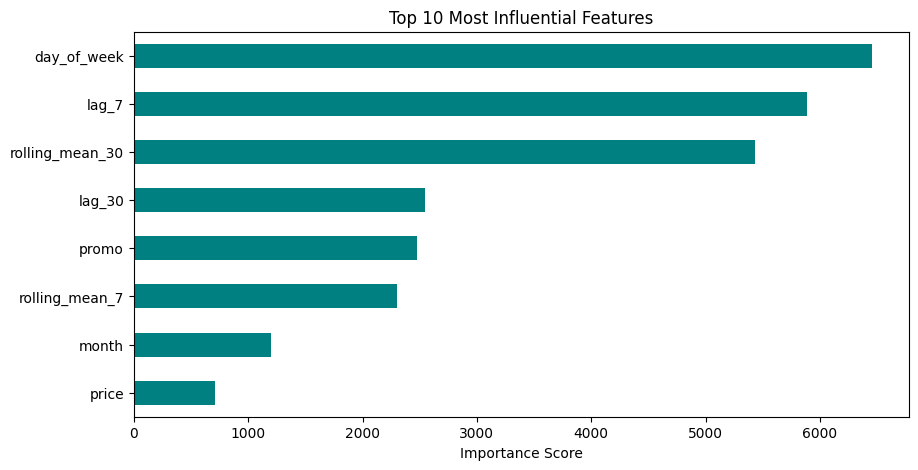

In [53]:
# Ploting feature Importance 
# A quick chart to show which features are most influential

importances = pd.Series(lgbm.feature_importances_, index=features)
top_features = importances.nlargest(10)                             # the top 10 features

plt.figure(figsize=(10, 5))
top_features.plot(kind='barh', color='teal')
plt.title('Top 10 Most Influential Features')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()                               # Putting the most important feature at the top
plt.show()

# 5.3 Deep Convolutional Neural Network (CNN)

In [26]:
def prepare_cnn_data(X_train, X_test):

    X_train_cnn = X_train.reshape(
        X_train.shape[0],
        X_train.shape[1],1)

    X_test_cnn = X_test.reshape(
        X_test.shape[0],
        X_test.shape[1],1)

    return X_train_cnn, X_test_cnn


# Apply transformation
X_train_cnn, X_test_cnn = prepare_cnn_data(
    X_train_scaled,
    X_test_scaled)

print("CNN Training Shape:", X_train_cnn.shape)
print("CNN Testing Shape :", X_test_cnn.shape)

CNN Training Shape: (3532611, 8, 1)
CNN Testing Shape : (883153, 8, 1)


In [27]:
# CNN Model 

def build_cnn_model(
    input_shape,
    num_classes):

    model = Sequential([Input(shape=input_shape),
                        Conv1D(filters=32
                               ,kernel_size=3
                               ,activation="relu"
                               ,padding="same"),
                        MaxPooling1D(pool_size=2)
                        ,Conv1D(filters=64
                                ,kernel_size=3
                                ,activation="relu"
                                ,padding="same")
                        ,MaxPooling1D(pool_size=2)
                        ,Flatten()
                        ,Dense(64,activation="relu")
                        ,Dropout(0.30),Dense(num_classes
                                             ,activation="softmax")])
    model.compile(optimizer="adam"
                  ,loss="sparse_categorical_crossentropy"
                  ,metrics=["accuracy"])

    return model

In [28]:
# Authomatic Class Detection

num_classes = len(np.unique(y_train))

print("Total Classes:", num_classes)

Total Classes: 3


In [29]:
# Build CNN

cnn_model = build_cnn_model(

    input_shape=(
        X_train_cnn.shape[1],
        X_train_cnn.shape[2])
    ,num_classes=num_classes)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 8, 32)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 4, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,787 (57.76 KB)

 Trainable params: 14,787 (57.76 KB)

 Non-trainable params: 0 (0.00 B)

### Basic CNN

In [30]:
# Basic CNN model
def build_basic_cnn_model(input_shape, num_classes):
   
    model = Sequential([
        Input(shape=input_shape),
        
        # Single shallow feature extraction layer
        Conv1D(filters=32, kernel_size=3, activation="relu", padding="same"),
        MaxPooling1D(pool_size=2),
        
        Flatten(),
        
        # Direct classification
        Dense(num_classes, activation="softmax")])
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"])
    return model

In [34]:
# Train Basic CNN
# Automatically count unique classes in your target data
num_classes = len(np.unique(y_train))

basic_model = build_basic_cnn_model(input_shape=(8, 1)
                                    ,num_classes=num_classes)

print("Training Basic CNN...")
basic_history = basic_model.fit(
    X_train_cnn, y_train,
    validation_split=0.20,
    epochs=30,
    batch_size=2048,
    verbose=1)

Training Basic CNN...
Epoch 1/30


I0000 00:00:1780920788.528671     138 service.cc:152] XLA service 0x7b060000c5f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780920788.528713     138 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780920788.528717     138 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780920788.728468     138 cuda_dnn.cc:529] Loaded cuDNN version 91002


  43/1380 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7345 - loss: 0.6922

I0000 00:00:1780920790.042243     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9003 - loss: 0.2442 - val_accuracy: 0.9146 - val_loss: 0.1943
Epoch 2/30
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9245 - loss: 0.1737 - val_accuracy: 0.9206 - val_loss: 0.1797
Epoch 3/30
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9272 - loss: 0.1665 - val_accuracy: 0.9232 - val_loss: 0.1755
Epoch 4/30
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9282 - loss: 0.1641 - val_accuracy: 0.9237 - val_loss: 0.1740
Epoch 5/30
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9286 - loss: 0.1629 - val_accuracy: 0.9238 - val_loss: 0.1738
Epoch 6/30
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9289 - loss: 0.1621 - val_accuracy: 0.9244 - val_loss: 0.1718
Epoch 7/30
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9291 - loss: 0.1616 - val_accuracy: 0.9245 - val_loss: 0.1710
Epoch 8/30
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9292 - loss: 0.1612 - val_accurac

In [36]:
# Basic CNN classification

y_pred_probs = basic_model.predict(X_test_cnn, batch_size=2048)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
print(classification_report(y_test, y_pred_labels))

432/432 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.95      0.94      0.94    449343
           1       0.91      0.93      0.92    400747
           2       0.82      0.75      0.78     33063

    accuracy                           0.93    883153
   macro avg       0.89      0.87      0.88    883153
weighted avg       0.93      0.93      0.93    883153



### Advance CNN Model

In [42]:
def build_advanced_cnn_model(input_shape, num_classes):
    
    model = Sequential([
        Input(shape=input_shape),
        
        # Conv Block 1
        Conv1D(filters=32, kernel_size=3, activation="relu", padding="same"),
        MaxPooling1D(pool_size=2),
        
        # Conv Block 2 (Deeper Feature Extraction)
        Conv1D(filters=64, kernel_size=3, activation="relu", padding="same"),
        MaxPooling1D(pool_size=2),
        
        Flatten(),
        
        # Regularization & Classification Dense Block
        Dense(64, activation="relu"),
        Dropout(0.30),  # Prevents co-adaptation of features
        Dense(num_classes, activation="softmax")])
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"])
    return model

In [43]:
# Train Advance CNN

num_classes = len(np.unique(y_train))
early_stop = EarlyStopping(monitor="val_loss"
                           ,patience=5, 
                           restore_best_weights=True)
advanced_model = build_advanced_cnn_model(input_shape=(8, 1)
                                          , num_classes=num_classes)

print("\nTraining Advanced CNN...")
advanced_history = advanced_model.fit(
    X_train_cnn, y_train,
    validation_split=0.20,
    epochs=30,
    batch_size=2048,
    callbacks=[early_stop],
    verbose=1)


Training Advanced CNN...
Epoch 1/30
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9183 - loss: 0.1958 - val_accuracy: 0.9235 - val_loss: 0.1748
Epoch 2/30
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9279 - loss: 0.1663 - val_accuracy: 0.9250 - val_loss: 0.1718
Epoch 3/30
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9292 - loss: 0.1627 - val_accuracy: 0.9262 - val_loss: 0.1679
Epoch 4/30
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9300 - loss: 0.1609 - val_accuracy: 0.9263 - val_loss: 0.1674
Epoch 5/30
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9303 - loss: 0.1600 - val_accuracy: 0.9264 - val_loss: 0.1650
Epoch 6/30
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9305 - loss: 0.1595 - val_accuracy: 0.9271 - val_loss: 0.1652
Epoch 7/30
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9305 - loss: 0.1591 - val_accuracy: 0.9272 - val_loss: 0.1640
Epoch 8/30
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accurac

In [49]:
# Advance CNN Classification
cnn_pred_prob = advanced_model.predict(X_test_cnn, batch_size=2048)
cnn_pred_labels = np.argmax(cnn_pred_prob, axis=1)
print(classification_report(y_test, cnn_pred_labels))

432/432 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.94      0.95      0.94    449343
           1       0.92      0.91      0.92    400747
           2       0.79      0.81      0.80     33063

    accuracy                           0.93    883153
   macro avg       0.88      0.89      0.89    883153
weighted avg       0.93      0.93      0.93    883153



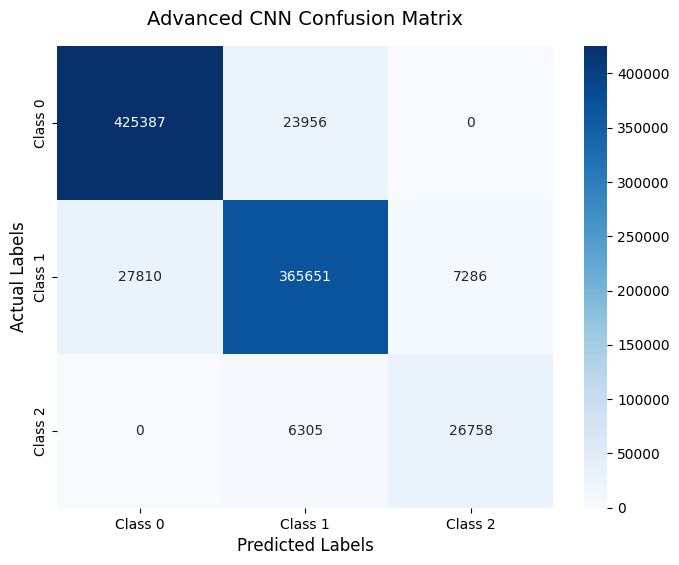

In [53]:
cm = confusion_matrix(y_test, cnn_pred_labels)

# Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues",  
    xticklabels=["Class 0", "Class 1", "Class 2"], 
    yticklabels=["Class 0", "Class 1", "Class 2"])

plt.title("Advanced CNN Confusion Matrix", fontsize=14, pad=15)
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("Actual Labels", fontsize=12)
plt.show()

In [35]:
cnn_model.save("retail_cnn_model.h5")

print("CNN Model Saved")

CNN Model Saved


# 5.4 Clustering

In [25]:
# Set random seed for reproducibility
np.random.seed(42)

# Apply PCA (Unified Preprocessing for Both Models)
# n_components=0.95 means PCA will keep enough principal components 

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Original shape: {X_scaled.shape}")
print(f"PCA reduced shape: {X_pca.shape}")

Original shape: (4415764, 111)
PCA reduced shape: (4415764, 98)


#### 5.4.1    K-Means

In [28]:
# K-Means with PCA Data

# Initialize and fit K-Means on the PCA-reduced data
kmeans_pca = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans_pca.fit_predict(X_pca)

# Evaluate K-Means
kmeans_labels_sample = kmeans_labels[sample_indices]
kmeans_sil = silhouette_score(X_pca_sample, kmeans_labels_sample)
kmeans_ars = adjusted_rand_score(y, kmeans_labels)

print("\n--- K-Means (with PCA) Results ---")
print(f"Sampled Silhouette Score: {kmeans_sil:.4f}")
print(f"Adjusted Rand Score: {kmeans_ars:.4f}")


--- K-Means (with PCA) Results ---
Sampled Silhouette Score: 0.0272
Adjusted Rand Score: 0.6035


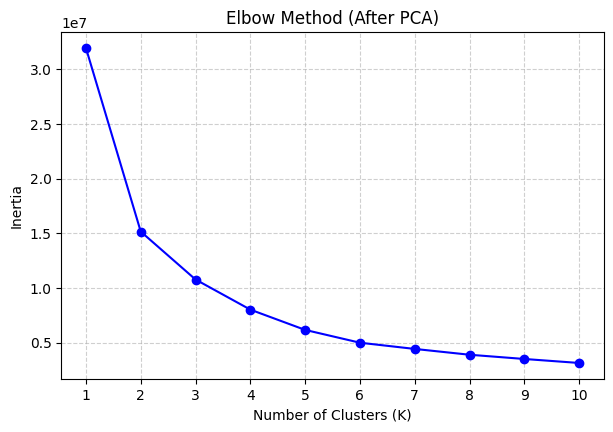

In [30]:
# compute PCA for 2D Visualization

# We explicitly project to 2 dimensions so we can map them to X and Y axes
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# The Elbow Method (Finding Optimal Clusters on PCA Data)

inertia = []
cluster_range = range(1, 11)

for k in cluster_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_pca_2d)
    inertia.append(model.inertia_)

# Plotting the Elbow Graph
plt.figure(figsize=(7, 4.5))
plt.plot(cluster_range, inertia, marker='o', linestyle='-', color='b')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method (After PCA)")
plt.xticks(cluster_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Advance Clustering

#### 5.4.2 Gaussian Mixture Model (GMM)

In [27]:
# Create a Sample Subset for Fast Silhouette Evaluation

sample_size = 15000
sample_indices = np.random.choice(
    X_pca.shape[0], 
    size=sample_size, 
    replace=False)

X_pca_sample = X_pca[sample_indices]

In [29]:
# Gaussian Mixture Model (GMM) with PCA Data

gmm_pca = GaussianMixture(n_components=3
                          ,covariance_type='full'
                          ,random_state=42)
gmm_pca.fit(X_pca)
gmm_labels = gmm_pca.predict(X_pca)

# Evaluate GMM
gmm_labels_sample = gmm_labels[sample_indices]
gmm_sil = silhouette_score(X_pca_sample, gmm_labels_sample)
gmm_ari = adjusted_rand_score(y, gmm_labels)

print("\n--- GMM (with PCA) Results ---")
print(f"Sampled Silhouette Score: {gmm_sil:.4f}")
print(f"GMM Adjusted Rand Index: {gmm_ari:.4f}")


--- GMM (with PCA) Results ---
Sampled Silhouette Score: 0.0236
GMM Adjusted Rand Index: 0.2402


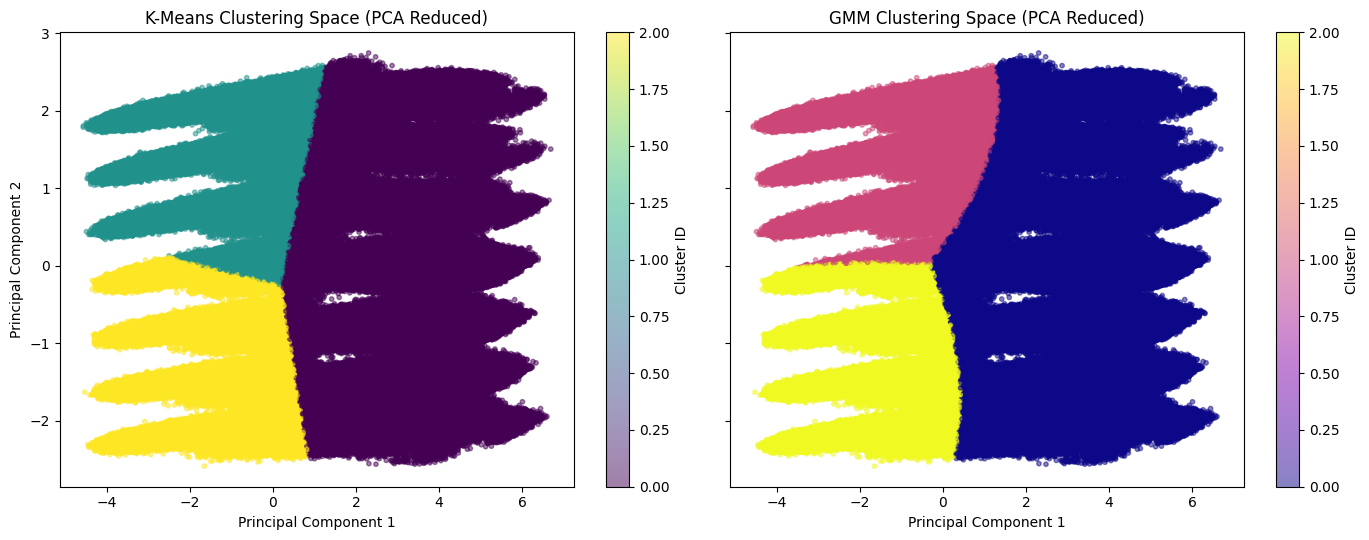

In [31]:
# Run Final Models (Assuming K=3 based on previous setup)

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca_2d)

# GMM
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm_labels = gmm.fit_predict(X_pca_2d)



# PCA Visualization (Side-by-Side Comparison)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True, sharey=True)

# Scatter plot for K-Means
scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=kmeans_labels, cmap='viridis', s=10, alpha=0.5)
axes[0].set_title("K-Means Clustering Space (PCA Reduced)")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
fig.colorbar(scatter1, ax=axes[0], label="Cluster ID")

# Scatter plot for GMM
scatter2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=gmm_labels, cmap='plasma', s=10, alpha=0.5)
axes[1].set_title("GMM Clustering Space (PCA Reduced)")
axes[1].set_xlabel("Principal Component 1")
fig.colorbar(scatter2, ax=axes[1], label="Cluster ID")

plt.tight_layout()
plt.show()

### SHAP Explainability 

In [61]:
np.random.seed(42)

# Select a smaller subset of the test data (for example 2,000 rows)
shap_sample_size = min(2000, X_test.shape[0])
sample_indices = np.random.choice(X_test.shape[0]
                                  , size=shap_sample_size
                                  , replace=False)

# If X_test is a pandas DataFrame:
X_test_sample = X_test.iloc[sample_indices]

# Run SHAP on the sample instead
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test_sample)

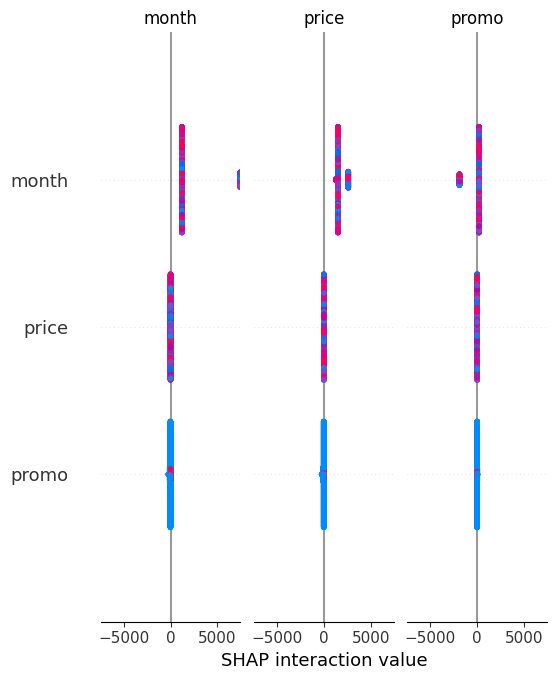

In [63]:
# Price dependency Plot
shap.summary_plot(shap_values
                  ,X_test_sample
                  ,feature_names=features)

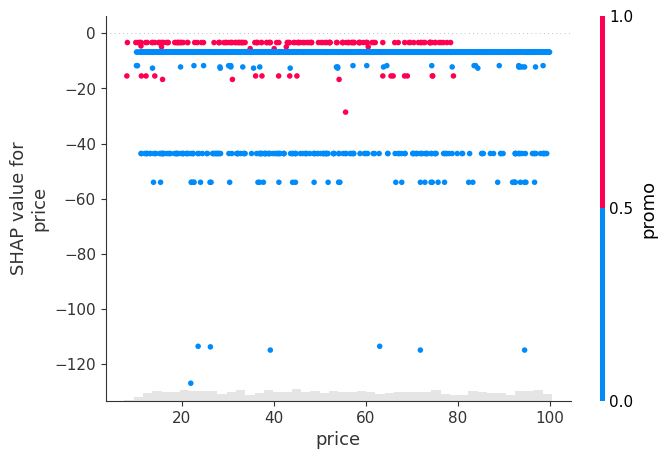

In [72]:
# Get standard SHAP values (not interaction values)
explainer = shap.TreeExplainer(lgbm)
shap_obj = explainer(X_test_sample)

# Plot using standard values
shap.plots.scatter(shap_obj[:, "price", 1]
                   , color=shap_obj[:, "promo", 1])

In [36]:
# confirming CNN model is saved
os.listdir("/kaggle/working")

['retail_sales.db', '.virtual_documents', 'retail_cnn_model.h5']

In [37]:
# Download CNN model to local computer
FileLink("retail_cnn_model.h5")

/kaggle/working/retail_cnn_model.h5